In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\uber-raw-data-aug14.csv")

In [3]:
df.head()

,Date/Time,Lat,Lon,Base
0,8/1/2014 0:03:00,40.7366,-73.9906,B02512
1,8/1/2014 0:09:00,40.7260,-73.9918,B02512
2,8/1/2014 0:12:00,40.7209,-74.0507,B02512
3,8/1/2014 0:12:00,40.7387,-73.9856,B02512
4,8/1/2014 0:12:00,40.7323,-74.0077,B02512


In [4]:
df.shape

(829275, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829275 entries, 0 to 829274
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  829275 non-null  object 
 1   Lat        829275 non-null  float64
 2   Lon        829275 non-null  float64
 3   Base       829275 non-null  object 
dtypes: float64(2), object(2)
memory usage: 25.3+ MB


In [6]:
df.describe()

,Lat,Lon
count,829275.000000,829275.000000
mean,40.737781,-73.970160
std,0.043628,0.061483
min,39.656900,-74.773700
25%,40.719000,-73.995800
50%,40.740700,-73.982600
75%,40.760500,-73.961200
max,41.318200,-72.335900


In [7]:
df.duplicated().sum()

np.int64(15882)

In [8]:
df =df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Date/Time"] = pd.to_datetime(df["Date/Time"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 813393 entries, 0 to 829274
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date/Time  813393 non-null  datetime64[ns]
 1   Lat        813393 non-null  float64       
 2   Lon        813393 non-null  float64       
 3   Base       813393 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 31.0+ MB


In [12]:
df.head()

,Date/Time,Lat,Lon,Base
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512


In [13]:
df["Day"] = df["Date/Time"].dt.day

In [14]:
df.head()

,Date/Time,Lat,Lon,Base,Day
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,1
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,1
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,1
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,1
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,1


In [15]:
df["Hours"] = df["Date/Time"].dt.hour

In [16]:
df.head()

,Date/Time,Lat,Lon,Base,Day,Hours
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,1,0
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,1,0
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,1,0
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,1,0
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,1,0


In [17]:
df["Weekday"] = df["Date/Time"].dt.day_name()

In [18]:
df.head()

,Date/Time,Lat,Lon,Base,Day,Hours,Weekday
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,1,0,Friday
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,1,0,Friday
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,1,0,Friday
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,1,0,Friday
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,1,0,Friday


In [19]:
x = df[["Lat", "Lon"]]

In [20]:
x.head()

,Lat,Lon
0,40.7366,-73.9906
1,40.7260,-73.9918
2,40.7209,-74.0507
3,40.7387,-73.9856
4,40.7323,-74.0077


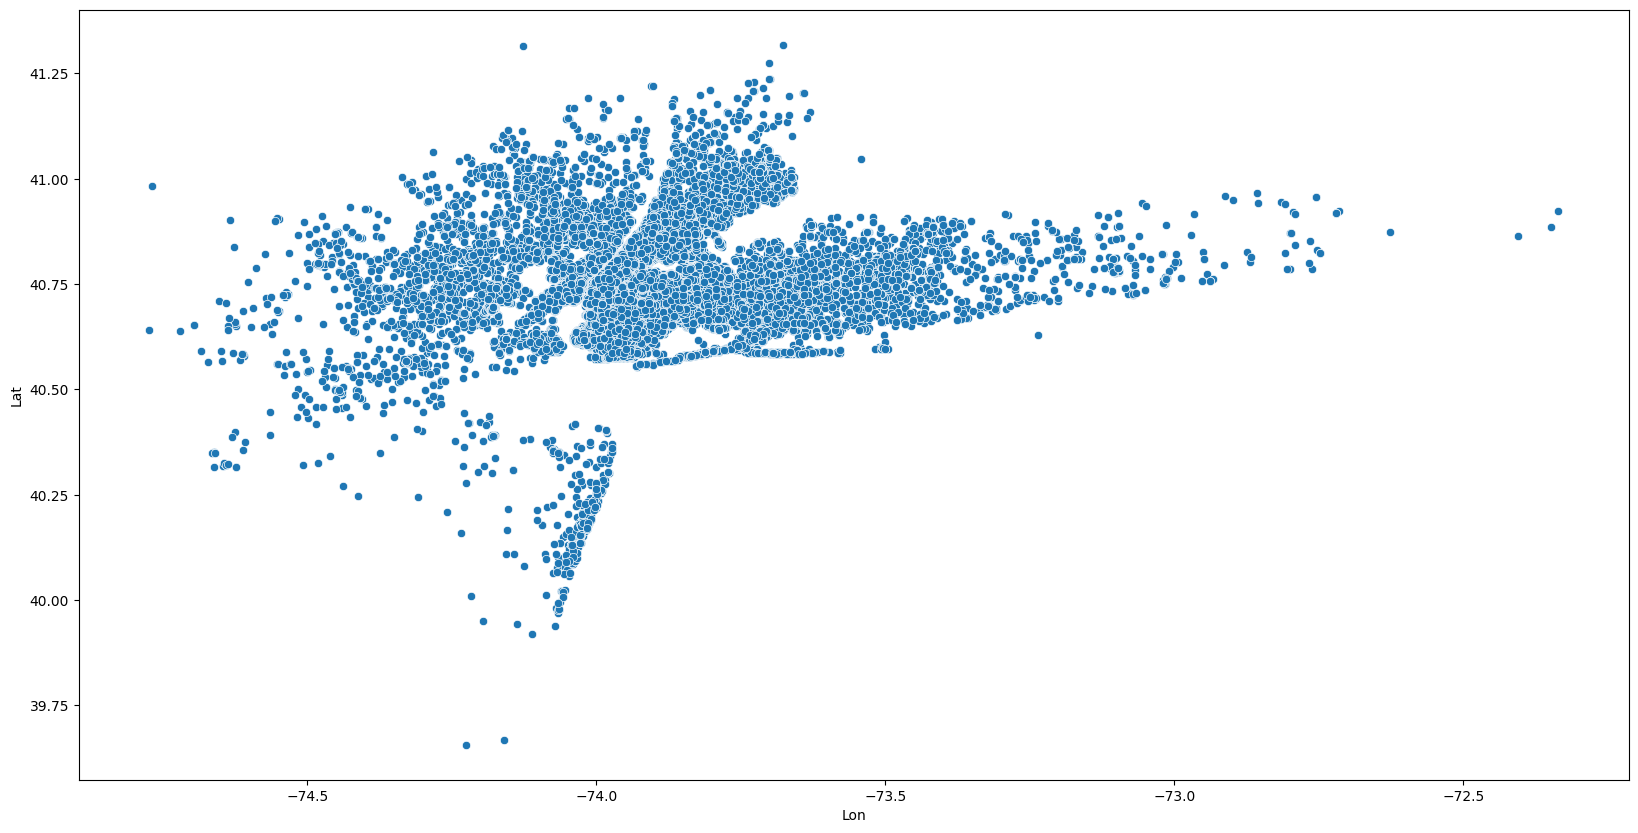

In [21]:
plt.figure(figsize = (20,10))
sns.scatterplot(x=df["Lon"] , y=df["Lat"])
plt.show()

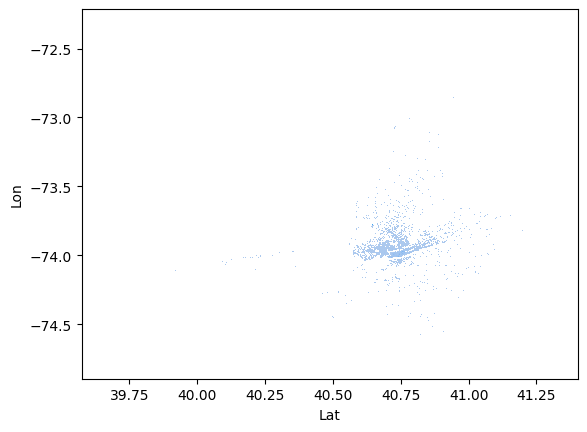

In [22]:
sns.histplot(data=x,x="Lat",y="Lon")
plt.show() 

In [23]:
ss = StandardScaler()
x_scaled = ss.fit_transform(x)

In [24]:
from sklearn.cluster import KMeans

In [25]:
c = []

In [26]:
for i in range(1, 11):
    model = KMeans(n_clusters = i, random_state = 42, n_init = 10)
    model.fit(x_scaled)
    c.append(model.inertia_)

In [27]:
c

[1626785.9999999935,
 1162677.7729046757,
 830948.3409678703,
 684388.6286061048,
 585499.4237492599,
 495744.8542793803,
 418360.02689130406,
 350864.0840678686,
 296095.66723215336,
 259476.99028345698]

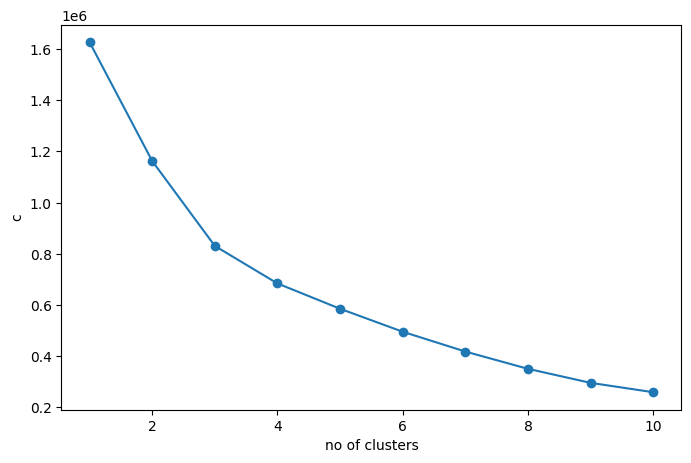

In [28]:
plt.figure(figsize = (8,5))
plt.plot(range(1,11), c, marker = "o")
plt.xlabel("no of clusters")
plt.ylabel("c")
plt.show()

In [29]:
model = KMeans(
    n_clusters = 5, random_state = 42, n_init = 10
)

In [30]:
cluster = model.fit_predict(x_scaled)

In [31]:
df["cluster"] = cluster

In [32]:
df.head()

,Date/Time,Lat,Lon,Base,Day,Hours,Weekday,cluster
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,1,0,Friday,0
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,1,0,Friday,4
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,1,0,Friday,4
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,1,0,Friday,0
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,1,0,Friday,0


In [33]:
df["cluster"].unique(),df["cluster"].value_counts() 

(array([0, 4, 3, 2, 1], dtype=int32),
 cluster
 0    424547
 4    287138
 2     61749
 1     31261
 3      8698
 Name: count, dtype: int64)

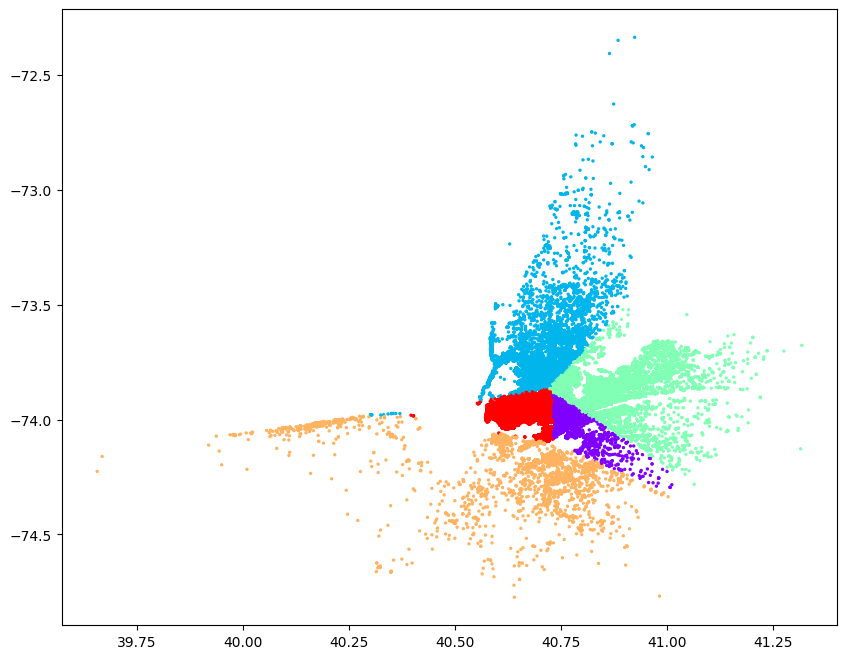

In [34]:
plt.figure(figsize = (10,8))
plt.scatter(x = df["Lat"], y = df["Lon"], c = df["cluster"], cmap = "rainbow", s = 2)
plt.show()

In [35]:
centeroid = ss.inverse_transform(model.cluster_centers_)

In [36]:
centeroid

array([[ 40.75520712, -73.98203585],
       [ 40.6697912 , -73.76361175],
       [ 40.8054572 , -73.89899625],
       [ 40.67188983, -74.19232242],
       [ 40.70660125, -73.98386837]])

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(x_scaled, test_size=0.20, random_state=42)

In [38]:
train_labels = model.predict(X_train)
test_labels = model.predict(X_test)

In [39]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, train_labels)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [40]:
pred = dt.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(test_labels, pred)
print("Accuracy:", acc*100)

Accuracy: 99.96987933291943


In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(x, test_size=0.2, random_state=42)
train_labels = model.predict(X_train)
test_labels = model.predict(X_test)
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, train_labels)
pred = dt.predict(X_test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(test_labels, pred)
print("Accuracy:", acc*100)

Accuracy: 100.0


C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
